# Exploratory Data Analysis – Google Play Store Apps

This notebook performs exploratory data analysis (EDA) on the Google Play Store Apps dataset.

The dataset contains information about applications available on the Google Play Store, including attributes such as category, rating, number of reviews, installs, price, and user sentiment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
apps = pd.read_csv("../data/raw/googleplaystore.csv")
reviews = pd.read_csv("../data/raw/googleplaystore_user_reviews.csv")

In [3]:
apps.shape

(10841, 13)

In [4]:
reviews.shape

(64295, 5)

In [5]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
apps.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [9]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [10]:
reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


In [11]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [13]:
apps.duplicated().sum()

483

In [14]:
apps["App"].duplicated().sum()

1181

In [15]:
reviews.duplicated().sum()

33616

# Outlier investigation

In [16]:
apps["Rating"].describe()

count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [17]:
apps[apps["Rating"] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [18]:
apps[apps["Rating"] < 1]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [19]:
apps["Price"].value_counts().head()

Price
0        10040
$0.99      148
$2.99      129
$1.99       73
$4.99       72
Name: count, dtype: int64

In [20]:
apps["Price"].describe()

count     10841
unique       93
top           0
freq      10040
Name: Price, dtype: object

In [21]:
apps.sort_values("Price", ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
7079,Filmi Gaane,FAMILY,4.4,572,Varies with device,"100,000+",Free,0,Everyone,Entertainment,"August 17, 2017",Varies with device,Varies with device
7072,Park Limousine: Realistic Limo Parking Simulator,FAMILY,4.8,4,25M,"1,000+",Free,0,Everyone,Simulation,"July 20, 2018",1.0,4.0 and up
7073,Animal Hunting: Sniper Shooting,GAME,NaN,0,48M,50+,Free,0,Teen,Action,"July 6, 2018",1.0,4.0 and up
7074,WISE- MOBILE PORTAL,TOOLS,NaN,3,1.0M,500+,Free,0,Everyone,Tools,"July 30, 2015",1.0.0.4,2.2 and up
7075,Inwestor mobile,FINANCE,3.2,124,7.2M,"10,000+",Free,0,Everyone,Finance,"January 3, 2018",1.2.3,4.1 and up
7076,BZ Straußenführer,TRAVEL_AND_LOCAL,4.3,291,14M,"10,000+",Free,0,Everyone,Travel & Local,"March 17, 2016",1.2.3,4.0 and up
7077,Zoosk Dating App: Meet Singles,DATING,4.0,516917,Varies with device,"10,000,000+",Free,0,Mature 17+,Dating,"August 2, 2018",Varies with device,Varies with device
7078,Putzmeister Experts,TOOLS,4.6,21,8.9M,"1,000+",Free,0,Everyone,Tools,"May 8, 2018",1.3,4.1 and up


In [22]:
apps["Installs"].value_counts().head()

Installs
1,000,000+     1579
10,000,000+    1252
100,000+       1169
10,000+        1054
1,000+          907
Name: count, dtype: int64

In [23]:
apps["Reviews"].describe()

count     10841
unique     6002
top           0
freq        596
Name: Reviews, dtype: object

In [24]:
apps.sort_values("Reviews", ascending=False).head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2989,GollerCepte Live Score,SPORTS,4.2,9992,31M,"1,000,000+",Free,0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,91k,"100,000+",Free,0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up
2723,SnipSnap Coupon App,SHOPPING,4.2,9975,18M,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
2705,SnipSnap Coupon App,SHOPPING,4.2,9975,18M,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
3079,US Open Tennis Championships 2018,SPORTS,4.0,9971,33M,"1,000,000+",Free,0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up


## Exploring Distributions


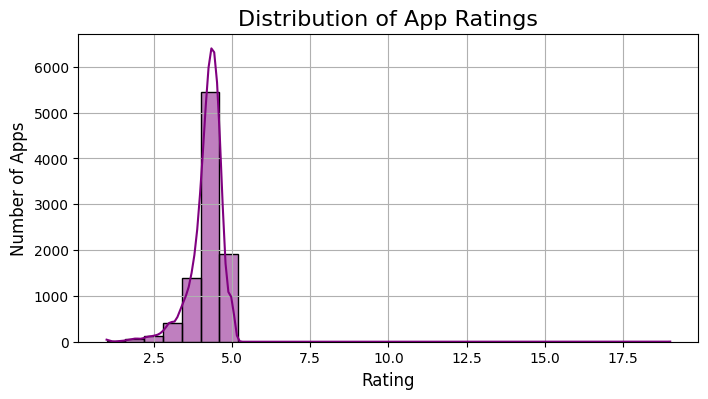

In [25]:
plt.figure(figsize=(8,4))
sns.histplot(apps["Rating"].dropna(), kde=True, bins=30, color='purple')

plt.title("Distribution of App Ratings", fontsize = 16)
plt.xlabel("Rating", fontsize = 12)
plt.ylabel("Number of Apps", fontsize = 12)
plt.grid(True)
plt.show()

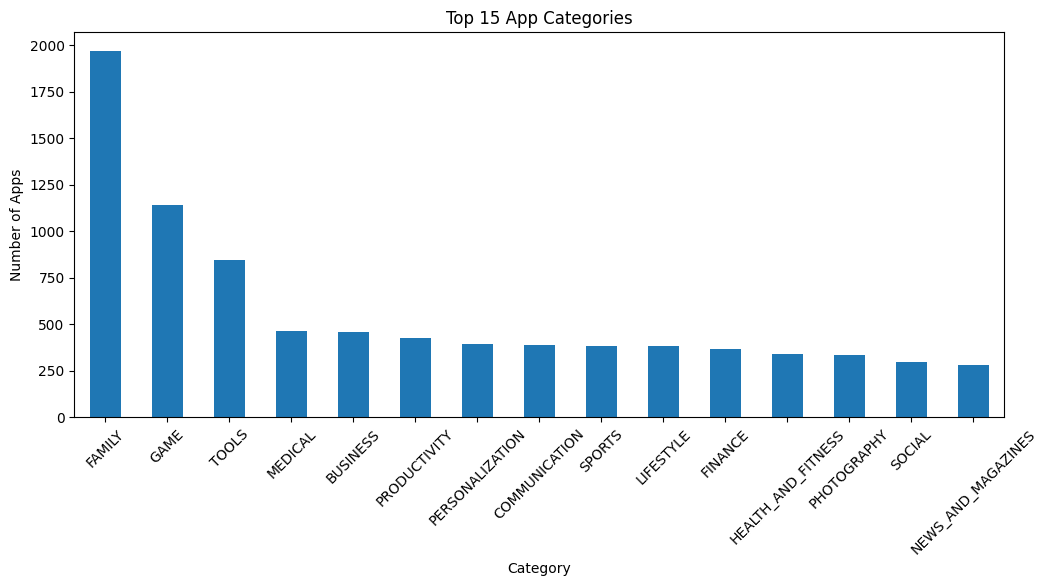

In [26]:
plt.figure(figsize=(12,5))

apps["Category"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()



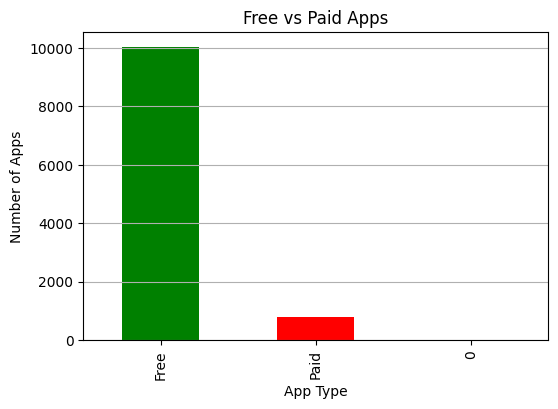

In [27]:
plt.figure(figsize=(6,4))

apps["Type"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.grid(axis="y")

plt.show()




## Investigating Relationships Between Variables

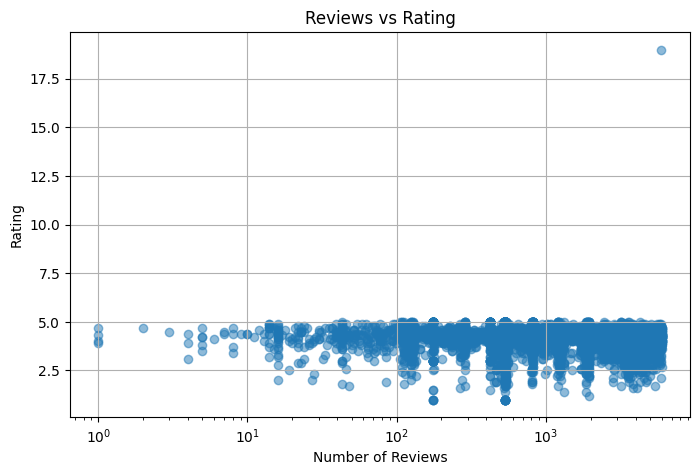

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(apps["Reviews"], apps["Rating"], alpha=0.5)

plt.xscale("log")

plt.title("Reviews vs Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.grid(True)

plt.show()

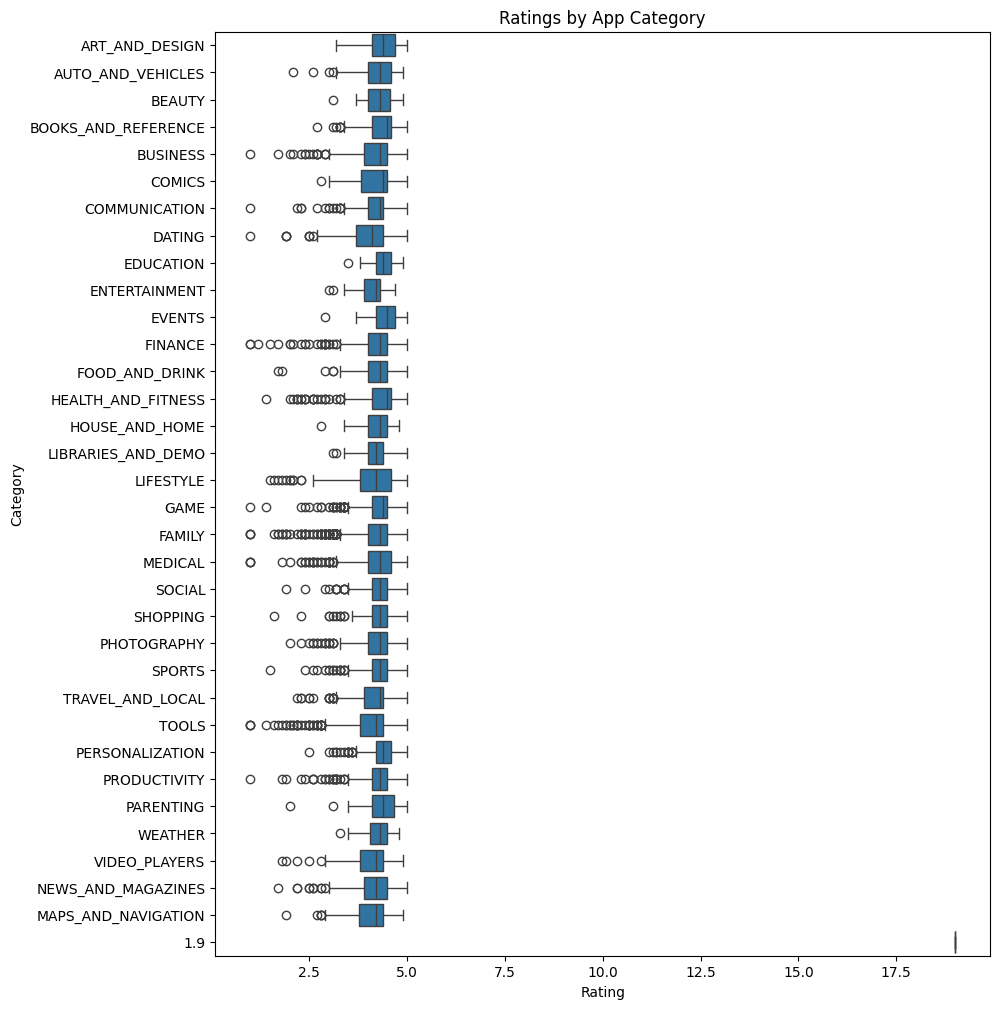

In [33]:
plt.figure(figsize=(10,12))

sns.boxplot(data=apps, y="Category", x="Rating")

plt.title("Ratings by App Category")

plt.show()



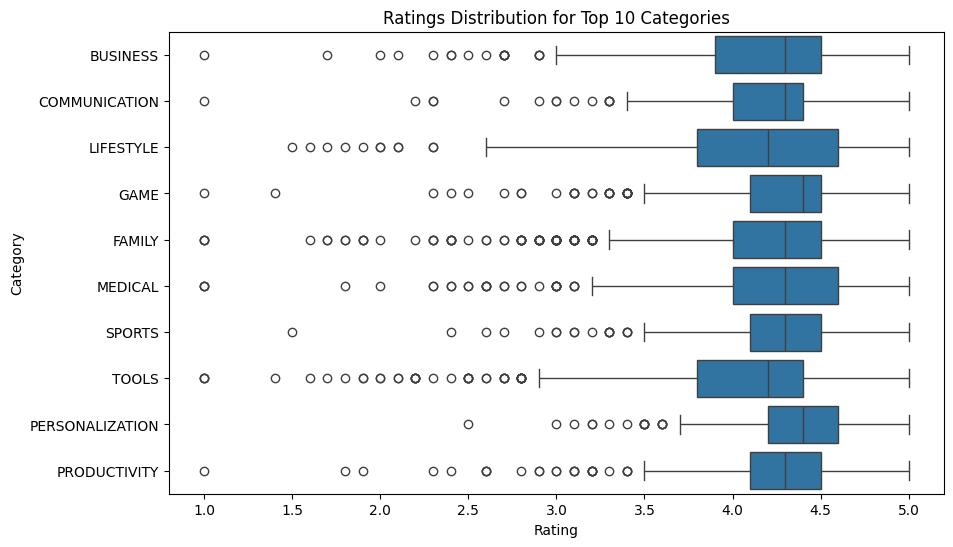

In [34]:
top_categories = apps["Category"].value_counts().head(10).index

plt.figure(figsize=(10,6))

sns.boxplot(
    data=apps[apps["Category"].isin(top_categories)],
    y="Category",
    x="Rating"
)

plt.title("Ratings Distribution for Top 10 Categories")

plt.show()

## Key Insights

- Most apps in the dataset have **high ratings**, typically around **4.0–4.5**.
- Some categories (such as **Family** and **Game**) contain many more apps than others.
- The majority of apps are **free**, while **paid apps are much fewer**.
- The number of reviews varies greatly between apps, showing that some apps receive far more user attention than others.
- Ratings across categories appear **fairly similar**, with no category clearly having much higher ratings.

## Possible Directions for a Final Project

- Study what factors influence **app popularity** (reviews, category, price, etc.).
- Compare **free vs paid apps** in terms of ratings and engagement.
- Analyze how **user reviews relate to app ratings**.